Loaded module: C:\Users\28547\anaconda_projects\disorder driven topological transition\QWZmodel.py


,check,value,expected,PASS
0,hermiticity_residual,0.000e+00,<= 1.0e-10,True
1,is_hermitian,True,True,True
2,particle_hole_residual,0.000e+00,<= 1.0e-10,True
3,has_particle_hole_symmetry,True,True,True
4,realspace_bloch_spectrum_residual,6.217e-15,<= 1.0e-10,True
5,realspace_bloch_spectrum_matches,True,True,True
6,dense_sparse_residual,0.000e+00,<= 1.0e-10,True
7,dense_sparse_match,True,True,True
8,public blocks reproduce H(k),1.110e-16,<= 1.0e-10,True
9,disordered spectrum has ±E pairing,1.243e-14,<= 1.0e-10,True



Passed 17/17 checks
Hilbert-space dimension: 60 = 2 x 6 x 5
Gamma-point energies: [-0.05  0.05]
Impurity-site mass: u-h = -0.350000


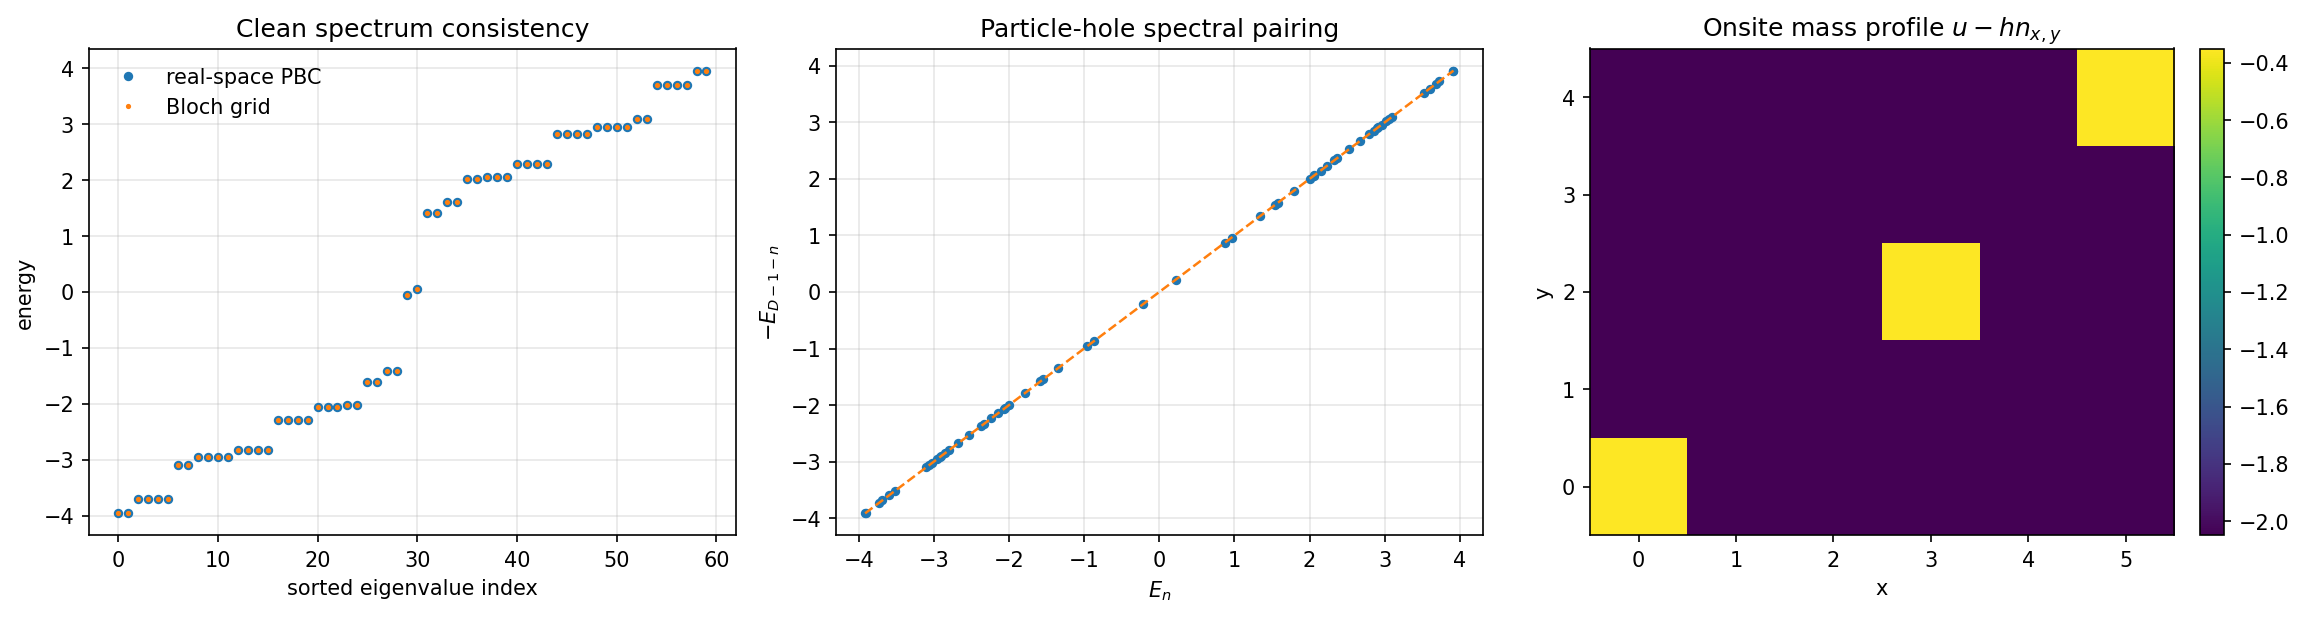


ALL QWZmodel.py SANITY CHECKS PASSED.


In [1]:
# ============================================================
# QWZmodel.py — production sanity check
#
# Notebook and QWZmodel.py should be in the same folder.
# This cell tests:
#   1. Hermiticity
#   2. particle-hole symmetry
#   3. real-space/Bloch consistency
#   4. dense/sparse consistency
#   5. public hopping-block convention
#   6. ±E spectral pairing
#   7. impurity term and onsite mass profile
#   8. PBC/OBC boundary behavior
#   9. coordinate validation
#  10. clean Gamma-point benchmark
# ============================================================

from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Import the local module freshly
# ------------------------------------------------------------

module_path = Path.cwd() / "QWZmodel.py"

if not module_path.exists():
    raise FileNotFoundError(
        f"Cannot find QWZmodel.py in:\n{Path.cwd()}\n\n"
        "Put QWZmodel.py and this notebook in the same folder."
    )

module_dir = str(module_path.parent.resolve())

if module_dir not in sys.path:
    sys.path.insert(0, module_dir)

import QWZmodel
importlib.reload(QWZmodel)

from QWZmodel import QWZModel

print(f"Loaded module: {Path(QWZmodel.__file__).resolve()}")


# ------------------------------------------------------------
# 1. Small test systems
# ------------------------------------------------------------

ATOL = 1.0e-10

Lx = 6
Ly = 5

params = {
    "t": 1.0,
    "u": -2.05,
    "A": 1.5,
}

impurities = [
    (0, 0),
    (3, 2),
    (5, 4),
]

h_imp = -1.70

model_pbc = QWZModel(
    Lx=Lx,
    Ly=Ly,
    pbc=True,
    **params,
)

model_obc = QWZModel(
    Lx=Lx,
    Ly=Ly,
    pbc=False,
    **params,
)

H0 = model_pbc.clean_hamiltonian(
    sparse=False
)

H = model_pbc.hamiltonian(
    impurities=impurities,
    h=h_imp,
    sparse=False,
)


# ------------------------------------------------------------
# Helper for recording test results
# ------------------------------------------------------------

checks = []


def add_check(name, value, passed, expected=""):
    checks.append(
        {
            "check": name,
            "value": value,
            "expected": expected,
            "PASS": bool(passed),
        }
    )


# ------------------------------------------------------------
# 2. Built-in consistency checks
# ------------------------------------------------------------

builtin = model_pbc.run_sanity_checks(
    impurities=impurities,
    h=h_imp,
    atol=ATOL,
    check_bloch_spectrum=True,
)

for key, value in builtin.items():

    is_boolean_test = (
        key.startswith("is_")
        or key.startswith("has_")
        or key.endswith("_match")
        or key.endswith("_matches")
    )

    if is_boolean_test:

        add_check(
            name=key,
            value=value,
            passed=bool(value),
            expected="True",
        )

    elif "residual" in key:

        value_float = float(value)

        add_check(
            name=key,
            value=f"{value_float:.3e}",
            passed=value_float <= ATOL,
            expected=f"<= {ATOL:.1e}",
        )


# ------------------------------------------------------------
# 3. Public blocks must reproduce the Bloch Hamiltonian
# ------------------------------------------------------------

kx = 0.37
ky = -1.11

Hk_from_blocks = (
    model_pbc.onsite_block
    + model_pbc.hopping_x * np.exp(1.0j * kx)
    + model_pbc.hopping_x.conj().T * np.exp(-1.0j * kx)
    + model_pbc.hopping_y * np.exp(1.0j * ky)
    + model_pbc.hopping_y.conj().T * np.exp(-1.0j * ky)
)

Hk_direct = model_pbc.bloch_hamiltonian(
    kx,
    ky,
)

block_bloch_residual = np.max(
    np.abs(Hk_from_blocks - Hk_direct)
)

add_check(
    name="public blocks reproduce H(k)",
    value=f"{block_bloch_residual:.3e}",
    passed=block_bloch_residual <= ATOL,
    expected=f"<= {ATOL:.1e}",
)


# ------------------------------------------------------------
# 4. Particle-hole symmetry at the spectrum level
#
# E_n should pair with -E_(D-1-n)
# ------------------------------------------------------------

evals_disordered = np.linalg.eigvalsh(H)

ph_spectrum_residual = np.max(
    np.abs(
        evals_disordered
        + evals_disordered[::-1]
    )
)

add_check(
    name="disordered spectrum has ±E pairing",
    value=f"{ph_spectrum_residual:.3e}",
    passed=ph_spectrum_residual <= ATOL,
    expected=f"<= {ATOL:.1e}",
)


# ------------------------------------------------------------
# 5. Impurity potential must be local and equal to -h sigma_z
# ------------------------------------------------------------

V_numerical = H - H0
V_expected = np.zeros_like(V_numerical)

for x, y in impurities:

    start = model_pbc.idx(
        x,
        y,
        0,
    )

    site_slice = slice(
        start,
        start + 2,
    )

    V_expected[
        site_slice,
        site_slice,
    ] = model_pbc.impurity_block(
        h_imp
    )

impurity_residual = np.max(
    np.abs(
        V_numerical
        - V_expected
    )
)

add_check(
    name="impurity term is local -h sigma_z",
    value=f"{impurity_residual:.3e}",
    passed=impurity_residual <= ATOL,
    expected=f"<= {ATOL:.1e}",
)


# ------------------------------------------------------------
# 6. Onsite mass profile
#
# Clean sites:      m = u
# Impurity sites:   m = u - h
# ------------------------------------------------------------

mass_profile = model_pbc.onsite_mass_profile(
    impurities=impurities,
    h=h_imp,
)

mass_profile_expected = np.full(
    (Ly, Lx),
    params["u"],
    dtype=float,
)

for x, y in impurities:
    mass_profile_expected[y, x] = (
        params["u"] - h_imp
    )

mass_profile_residual = np.max(
    np.abs(
        mass_profile
        - mass_profile_expected
    )
)

add_check(
    name="onsite mass profile equals u-h on impurities",
    value=f"{mass_profile_residual:.3e}",
    passed=mass_profile_residual <= ATOL,
    expected=f"<= {ATOL:.1e}",
)


# ------------------------------------------------------------
# 7. PBC must wrap; OBC must not wrap
# ------------------------------------------------------------

H0_pbc = model_pbc.clean_hamiltonian(
    sparse=False
)

H0_obc = model_obc.clean_hamiltonian(
    sparse=False
)


def extract_site_block(
    matrix,
    site_a,
    site_b,
    model,
):
    ia = model.idx(
        site_a[0],
        site_a[1],
        0,
    )

    ib = model.idx(
        site_b[0],
        site_b[1],
        0,
    )

    return matrix[
        ia:ia + 2,
        ib:ib + 2,
    ]


# Hopping from the final x-column to the first x-column
wrap_block_pbc = extract_site_block(
    H0_pbc,
    site_a=(Lx - 1, 0),
    site_b=(0, 0),
    model=model_pbc,
)

wrap_block_obc = extract_site_block(
    H0_obc,
    site_a=(Lx - 1, 0),
    site_b=(0, 0),
    model=model_obc,
)

pbc_wrap_residual = np.max(
    np.abs(
        wrap_block_pbc
        - model_pbc.hopping_x
    )
)

obc_wrap_norm = np.max(
    np.abs(
        wrap_block_obc
    )
)

add_check(
    name="PBC x-boundary hopping is present",
    value=f"{pbc_wrap_residual:.3e}",
    passed=pbc_wrap_residual <= ATOL,
    expected=f"<= {ATOL:.1e}",
)

add_check(
    name="OBC x-boundary hopping is absent",
    value=f"{obc_wrap_norm:.3e}",
    passed=obc_wrap_norm <= ATOL,
    expected=f"<= {ATOL:.1e}",
)


# ------------------------------------------------------------
# 8. OBC coordinates must not silently wrap
# ------------------------------------------------------------

try:
    model_obc.normalize_site(
        -1,
        0,
    )
    obc_rejects_outside = False

except IndexError:
    obc_rejects_outside = True

add_check(
    name="OBC rejects out-of-range coordinates",
    value=obc_rejects_outside,
    passed=obc_rejects_outside,
    expected="True",
)


# ------------------------------------------------------------
# 9. Duplicate impurities after PBC wrapping must be rejected
#
# (0,0) and (Lx,0) represent the same PBC site.
# ------------------------------------------------------------

try:
    model_pbc.canonicalize_impurities(
        [
            (0, 0),
            (Lx, 0),
        ]
    )

    duplicate_rejected = False

except ValueError:
    duplicate_rejected = True

add_check(
    name="duplicate impurities after PBC wrapping are rejected",
    value=duplicate_rejected,
    passed=duplicate_rejected,
    expected="True",
)


# ------------------------------------------------------------
# 10. Physical clean-system benchmark at Gamma
#
# H(Gamma) = (u + 2t) sigma_z
#
# For u=-2.05 and t=1:
#
#     E(Gamma) = ±0.05
# ------------------------------------------------------------

gamma_evals = model_pbc.dispersion(
    0.0,
    0.0,
)

gamma_mass = (
    params["u"]
    + 2.0 * params["t"]
)

gamma_expected = np.array(
    [
        -abs(gamma_mass),
        +abs(gamma_mass),
    ]
)

gamma_residual = np.max(
    np.abs(
        gamma_evals
        - gamma_expected
    )
)

add_check(
    name="Gamma-point energies match ±|u+2t|",
    value=f"{gamma_residual:.3e}",
    passed=gamma_residual <= ATOL,
    expected=f"<= {ATOL:.1e}",
)


# ------------------------------------------------------------
# 11. Display the test table
# ------------------------------------------------------------

results = pd.DataFrame(checks)

display(results)

n_passed = int(
    results["PASS"].sum()
)

n_total = len(results)

print()
print(f"Passed {n_passed}/{n_total} checks")
print(
    "Hilbert-space dimension:",
    f"{model_pbc.dim} = 2 x {Lx} x {Ly}",
)
print(
    "Gamma-point energies:",
    gamma_evals,
)
print(
    "Impurity-site mass:",
    f"u-h = {params['u'] - h_imp:.6f}",
)


# ------------------------------------------------------------
# 12. Diagnostic plots
# ------------------------------------------------------------

clean_realspace_spectrum = np.sort(
    np.linalg.eigvalsh(H0)
)

clean_bloch_spectrum = (
    model_pbc.clean_spectrum_from_bloch_grid()
)

spectrum_indices = np.arange(
    model_pbc.dim
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15.5, 4.2),
    dpi=150,
)

# Real-space versus Bloch spectrum
axes[0].plot(
    spectrum_indices,
    clean_realspace_spectrum,
    "o",
    markersize=3.5,
    label="real-space PBC",
)

axes[0].plot(
    spectrum_indices,
    clean_bloch_spectrum,
    ".",
    markersize=3.0,
    label="Bloch grid",
)

axes[0].set_xlabel(
    "sorted eigenvalue index"
)

axes[0].set_ylabel(
    "energy"
)

axes[0].set_title(
    "Clean spectrum consistency"
)

axes[0].grid(
    alpha=0.3
)

axes[0].legend(
    frameon=False
)


# Particle-hole spectral pairing
axes[1].plot(
    evals_disordered,
    -evals_disordered[::-1],
    "o",
    markersize=3.5,
)

energy_min = float(
    evals_disordered.min()
)

energy_max = float(
    evals_disordered.max()
)

axes[1].plot(
    [energy_min, energy_max],
    [energy_min, energy_max],
    "--",
    linewidth=1.2,
)

axes[1].set_xlabel(
    r"$E_n$"
)

axes[1].set_ylabel(
    r"$-E_{D-1-n}$"
)

axes[1].set_title(
    "Particle-hole spectral pairing"
)

axes[1].grid(
    alpha=0.3
)


# Onsite mass profile
image = axes[2].imshow(
    mass_profile,
    origin="lower",
    aspect="equal",
)

axes[2].set_xlabel(
    "x"
)

axes[2].set_ylabel(
    "y"
)

axes[2].set_title(
    r"Onsite mass profile $u-hn_{x,y}$"
)

axes[2].set_xticks(
    range(Lx)
)

axes[2].set_yticks(
    range(Ly)
)

fig.colorbar(
    image,
    ax=axes[2],
    fraction=0.046,
    pad=0.04,
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. Final pass/fail decision
# ------------------------------------------------------------

failed_checks = results.loc[
    ~results["PASS"],
    "check",
].tolist()

if failed_checks:
    raise AssertionError(
        "Sanity check failed:\n- "
        + "\n- ".join(failed_checks)
    )

print()
print(
    "ALL QWZmodel.py SANITY CHECKS PASSED."
)

Loaded QWZ module:
C:\Users\28547\anaconda_projects\disorder driven topological transition\QWZmodel.py

Loaded finite-scaling module:
C:\Users\28547\anaconda_projects\disorder driven topological transition\finite_scaling.py


,check,value,expected,PASS
0,fixed-count ensemble has exact requested count,3,3,True
1,fixed-count sampling is reproducible,True,True,True
2,fixed-count sample has no duplicate sites,3,3,True
3,Bernoulli sampling is reproducible,True,True,True
4,Bernoulli sites lie inside the lattice,True,True,True
5,clean Bott phase sequence,"[0, 1, -1, 0]","[0, 1, -1, 0]",True
6,clean Bott values are integer-quantized,6.661e-16,<= 1.0e-10,True
7,Bott-point raw realizations are topological,True,True,True
8,Bott summary returns P_absB1=1,1.000000,1.0,True
9,slice Hamiltonian matches full real-space block,0.000e+00,<= 1.0e-10,True



Passed 26/26 checks

Fixed-count impurities:
((5, 9), (6, 9), (8, 9))

Bernoulli impurities:
((6, 2), (3, 4), (5, 6), (6, 6), (2, 9))

Bott sequence: [0, 1, -1, 0]
gamma_min_pos: 4.33125067e-02
xi_M: 23.088019
Lambda: 7.696006
Lyapunov pairing residual: 1.725882e-03


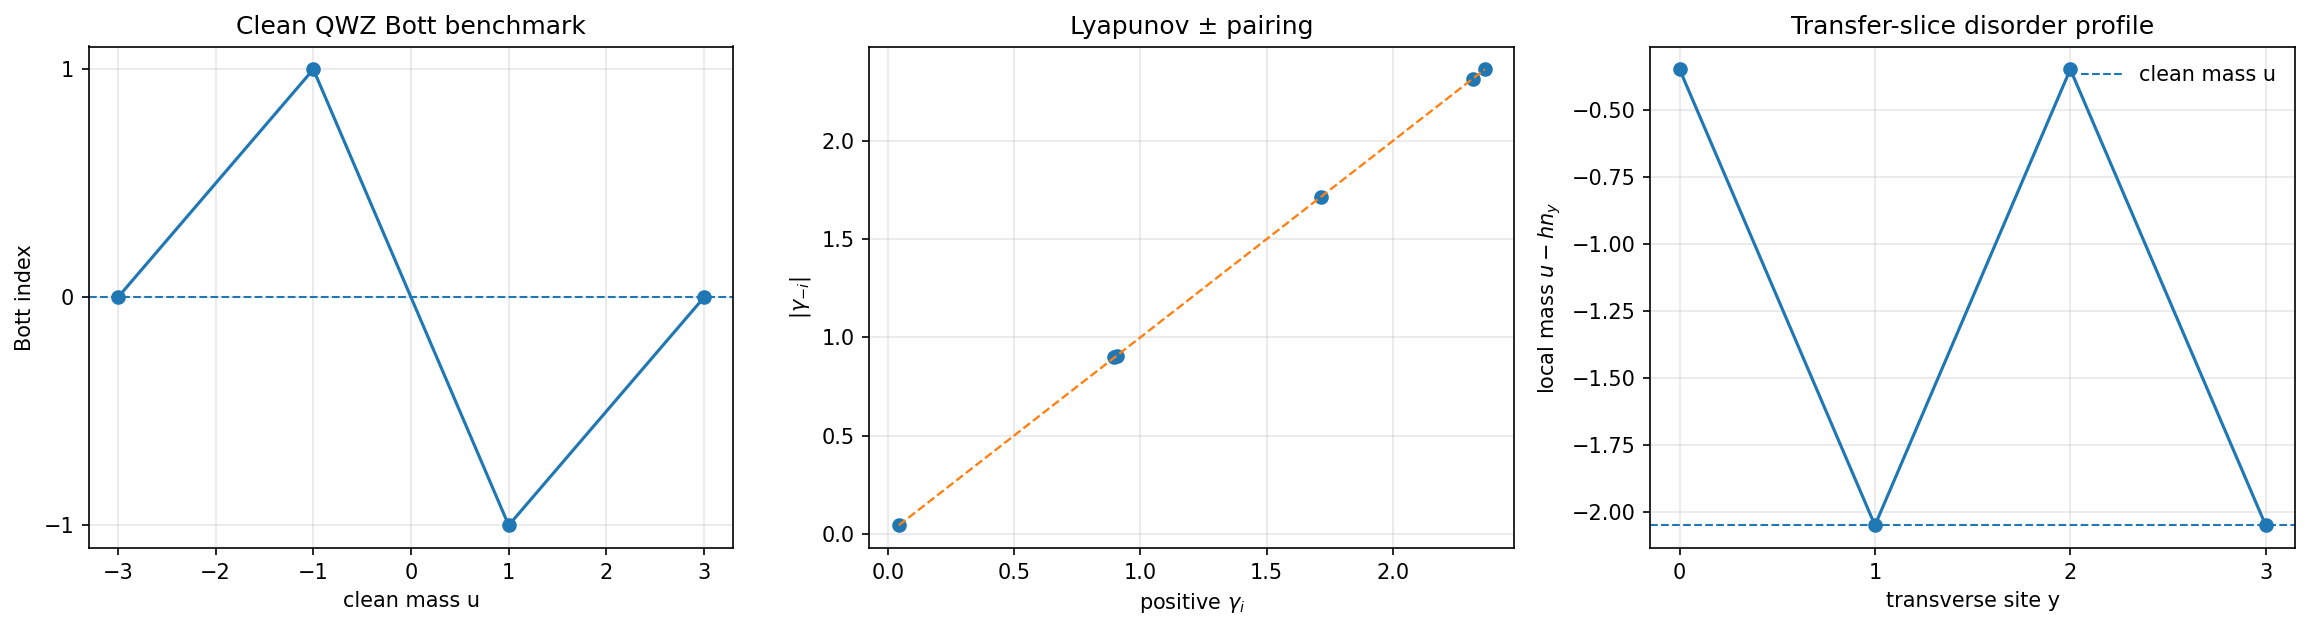


ALL finite_scaling.py SANITY CHECKS PASSED.


In [2]:
# ============================================================
# finite_scaling.py — production sanity check
#
# QWZmodel.py, finite_scaling.py, and this notebook
# should be in the same folder.
#
# Tests:
#   1. fixed-count and Bernoulli disorder ensembles
#   2. clean Bott-index benchmarks
#   3. Bott realization summaries
#   4. QWZ slice Hamiltonian consistency
#   5. inter-slice hopping consistency
#   6. transfer recurrence
#   7. QR Lyapunov calculation
#   8. Lyapunov ± pairing
#   9. deterministic reproducibility
#  10. CSV checkpoint/restart behavior
# ============================================================

from pathlib import Path
from tempfile import TemporaryDirectory
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 0. Import both local modules freshly
# ------------------------------------------------------------

current_folder = Path.cwd()

qwz_path = current_folder / "QWZmodel.py"
finite_path = current_folder / "finite_scaling.py"

if not qwz_path.exists():
    raise FileNotFoundError(
        f"Cannot find QWZmodel.py in:\n{current_folder}"
    )

if not finite_path.exists():
    raise FileNotFoundError(
        f"Cannot find finite_scaling.py in:\n{current_folder}"
    )

folder_string = str(current_folder.resolve())

if folder_string not in sys.path:
    sys.path.insert(0, folder_string)

import QWZmodel
import finite_scaling

importlib.reload(QWZmodel)
importlib.reload(finite_scaling)

from QWZmodel import QWZModel
import finite_scaling as fs

print("Loaded QWZ module:")
print(Path(QWZmodel.__file__).resolve())

print("\nLoaded finite-scaling module:")
print(Path(finite_scaling.__file__).resolve())


# ------------------------------------------------------------
# Helper for recording tests
# ------------------------------------------------------------

ATOL = 1.0e-10

checks = []


def add_check(name, value, passed, expected=""):
    checks.append(
        {
            "check": name,
            "value": value,
            "expected": expected,
            "PASS": bool(passed),
        }
    )


# ============================================================
# 1. Disorder ensemble tests
# ============================================================

sampling_model = QWZModel(
    Lx=10,
    Ly=10,
    t=1.0,
    u=-2.05,
    A=1.5,
    pbc=True,
)

p_target = 0.03

fixed_a = fs.sample_fixed_count_impurities(
    sampling_model,
    density=p_target,
    seed=1234,
)

fixed_b = fs.sample_fixed_count_impurities(
    sampling_model,
    density=p_target,
    seed=1234,
)

bernoulli_a = fs.sample_bernoulli_impurities(
    sampling_model,
    density=p_target,
    seed=5678,
)

bernoulli_b = fs.sample_bernoulli_impurities(
    sampling_model,
    density=p_target,
    seed=5678,
)

expected_fixed_count = 3

add_check(
    name="fixed-count ensemble has exact requested count",
    value=len(fixed_a),
    passed=len(fixed_a) == expected_fixed_count,
    expected=expected_fixed_count,
)

add_check(
    name="fixed-count sampling is reproducible",
    value=fixed_a == fixed_b,
    passed=fixed_a == fixed_b,
    expected=True,
)

add_check(
    name="fixed-count sample has no duplicate sites",
    value=len(set(fixed_a)),
    passed=len(set(fixed_a)) == len(fixed_a),
    expected=len(fixed_a),
)

add_check(
    name="Bernoulli sampling is reproducible",
    value=bernoulli_a == bernoulli_b,
    passed=bernoulli_a == bernoulli_b,
    expected=True,
)

bernoulli_sites_valid = all(
    0 <= x < sampling_model.Lx
    and 0 <= y < sampling_model.Ly
    for x, y in bernoulli_a
)

add_check(
    name="Bernoulli sites lie inside the lattice",
    value=bernoulli_sites_valid,
    passed=bernoulli_sites_valid,
    expected=True,
)


# ============================================================
# 2. Clean Bott-index benchmarks
#
# For this QWZ convention:
#
#   u = -3  -> Bott  0
#   u = -1  -> Bott +1
#   u = +1  -> Bott -1
#   u = +3  -> Bott  0
# ============================================================

benchmark_u = [-3.0, -1.0, 1.0, 3.0]
expected_bott = [0, 1, -1, 0]

bott_results = []

for u_value in benchmark_u:

    model = QWZModel(
        Lx=6,
        Ly=6,
        t=1.0,
        u=u_value,
        A=1.5,
        pbc=True,
    )

    result = fs.bott_realization(
        model,
        h=0.0,
        impurities=[],
        fermi_energy=0.0,
    )

    bott_results.append(result)

computed_bott = [
    int(result["bott"])
    for result in bott_results
]

largest_integer_residual = max(
    float(result["integer_residual"])
    for result in bott_results
)

add_check(
    name="clean Bott phase sequence",
    value=computed_bott,
    passed=computed_bott == expected_bott,
    expected=expected_bott,
)

add_check(
    name="clean Bott values are integer-quantized",
    value=f"{largest_integer_residual:.3e}",
    passed=largest_integer_residual <= ATOL,
    expected=f"<= {ATOL:.1e}",
)


# ============================================================
# 3. Bott-point realization and summary test
# ============================================================

topological_model = QWZModel(
    Lx=4,
    Ly=4,
    t=1.0,
    u=-1.0,
    A=1.5,
    pbc=True,
)

bott_raw = fs.bott_point(
    topological_model,
    h=0.0,
    density=0.0,
    n_realizations=3,
    ensemble="fixed_count",
    seed0=100,
)

bott_summary = fs.summarize_bott_raw(
    bott_raw
)

all_topological = bool(
    np.all(
        bott_raw["abs_bott"].to_numpy()
        == 1
    )
)

summary_probability = float(
    bott_summary["P_absB1"].iloc[0]
)

add_check(
    name="Bott-point raw realizations are topological",
    value=all_topological,
    passed=all_topological,
    expected=True,
)

add_check(
    name="Bott summary returns P_absB1=1",
    value=f"{summary_probability:.6f}",
    passed=np.isclose(summary_probability, 1.0),
    expected="1.0",
)


# ============================================================
# 4. Slice Hamiltonian versus full real-space Hamiltonian
# ============================================================

M = 4

full_strip_model = QWZModel(
    Lx=3,
    Ly=M,
    t=1.0,
    u=-2.05,
    A=1.5,
    pbc=(False, True),
)

slice_mask = np.array(
    [True, False, True, False],
    dtype=bool,
)

h_test = -1.70

slice_impurities = [
    (1, y)
    for y in range(M)
    if slice_mask[y]
]

full_hamiltonian = full_strip_model.hamiltonian(
    impurities=slice_impurities,
    h=h_test,
    sparse=False,
)

slice_indices = [
    full_strip_model.idx(1, y, orbital)
    for y in range(M)
    for orbital in range(2)
]

next_slice_indices = [
    full_strip_model.idx(2, y, orbital)
    for y in range(M)
    for orbital in range(2)
]

slice_from_full = full_hamiltonian[
    np.ix_(
        slice_indices,
        slice_indices,
    )
]

transfer_model = fs.transfer_model_from_template(
    full_strip_model,
    width=M,
)

slice_direct = fs.build_slice_hamiltonian(
    transfer_model,
    slice_mask,
    h=h_test,
)

slice_residual = np.max(
    np.abs(
        slice_from_full
        - slice_direct
    )
)

slice_hermiticity = np.max(
    np.abs(
        slice_direct
        - slice_direct.conj().T
    )
)

add_check(
    name="slice Hamiltonian matches full real-space block",
    value=f"{slice_residual:.3e}",
    passed=slice_residual <= ATOL,
    expected=f"<= {ATOL:.1e}",
)

add_check(
    name="slice Hamiltonian is Hermitian",
    value=f"{slice_hermiticity:.3e}",
    passed=slice_hermiticity <= ATOL,
    expected=f"<= {ATOL:.1e}",
)


# ------------------------------------------------------------
# Inter-slice hopping consistency
# ------------------------------------------------------------

interslice_from_full = full_hamiltonian[
    np.ix_(
        slice_indices,
        next_slice_indices,
    )
]

interslice_expected = np.kron(
    np.eye(M),
    full_strip_model.hopping_x,
)

interslice_residual = np.max(
    np.abs(
        interslice_from_full
        - interslice_expected
    )
)

add_check(
    name="inter-slice hopping uses QWZmodel.hopping_x",
    value=f"{interslice_residual:.3e}",
    passed=interslice_residual <= ATOL,
    expected=f"<= {ATOL:.1e}",
)


# ============================================================
# 5. Transfer recurrence test
# ============================================================

workspace = fs.prepare_transfer_workspace(
    transfer_model,
    energy=0.0,
)

rng = np.random.default_rng(2026)

psi_previous = (
    rng.normal(size=workspace.slice_dim)
    + 1.0j * rng.normal(size=workspace.slice_dim)
)

psi_current = (
    rng.normal(size=workspace.slice_dim)
    + 1.0j * rng.normal(size=workspace.slice_dim)
)

recurrence_residual = fs.transfer_recurrence_residual(
    workspace,
    slice_mask,
    h=h_test,
    psi_previous=psi_previous,
    psi_current=psi_current,
)

add_check(
    name="transfer matrix satisfies Schrödinger recurrence",
    value=f"{recurrence_residual:.3e}",
    passed=recurrence_residual <= ATOL,
    expected=f"<= {ATOL:.1e}",
)


# ============================================================
# 6. QR Lyapunov calculation
# ============================================================

tm_model = fs.transfer_model_from_template(
    QWZModel(
        Lx=4,
        Ly=4,
        t=1.0,
        u=-2.05,
        A=1.5,
        pbc=True,
    ),
    width=3,
)

tm_result_a = fs.lyapunov_exponents_qr(
    tm_model,
    h=-3.45,
    density=0.03,
    n_slices=1200,
    energy=0.0,
    seed=2026,
    qr_interval=1,
    return_gammas=True,
)

tm_result_b = fs.lyapunov_exponents_qr(
    tm_model,
    h=-3.45,
    density=0.03,
    n_slices=1200,
    energy=0.0,
    seed=2026,
    qr_interval=1,
    return_gammas=True,
)

gammas = np.asarray(
    tm_result_a["gammas"],
    dtype=float,
)

same_seed_gamma_match = np.isclose(
    tm_result_a["gamma_min_pos"],
    tm_result_b["gamma_min_pos"],
    rtol=0.0,
    atol=1.0e-14,
)

same_seed_lambda_match = np.isclose(
    tm_result_a["Lambda"],
    tm_result_b["Lambda"],
    rtol=0.0,
    atol=1.0e-14,
)

positive_count = int(
    np.sum(
        gammas > 1.0e-10
    )
)

expected_positive_count = (
    tm_result_a["M"] * 2
)

pairing_residual = float(
    tm_result_a[
        "lyapunov_pairing_residual"
    ]
)

add_check(
    name="Lyapunov calculation is reproducible for fixed seed",
    value=same_seed_gamma_match,
    passed=same_seed_gamma_match,
    expected=True,
)

add_check(
    name="Lambda is reproducible for fixed seed",
    value=same_seed_lambda_match,
    passed=same_seed_lambda_match,
    expected=True,
)

add_check(
    name="all Lyapunov exponents are finite",
    value=bool(np.all(np.isfinite(gammas))),
    passed=bool(np.all(np.isfinite(gammas))),
    expected=True,
)

add_check(
    name="Lyapunov exponents are sorted",
    value=bool(np.all(np.diff(gammas) >= 0.0)),
    passed=bool(np.all(np.diff(gammas) >= 0.0)),
    expected=True,
)

add_check(
    name="half of Lyapunov exponents are positive",
    value=positive_count,
    passed=positive_count == expected_positive_count,
    expected=expected_positive_count,
)

add_check(
    name="finite-length Lyapunov ± pairing is accurate",
    value=f"{pairing_residual:.3e}",
    passed=pairing_residual < 2.0e-2,
    expected="< 2e-2",
)

lambda_value = float(
    tm_result_a["Lambda"]
)

add_check(
    name="normalized localization length is finite and positive",
    value=f"{lambda_value:.6f}",
    passed=np.isfinite(lambda_value) and lambda_value > 0.0,
    expected="finite and > 0",
)


# ============================================================
# 7. CSV checkpoint/restart sanity check
# ============================================================

with TemporaryDirectory() as temporary_directory:

    temporary_directory = Path(
        temporary_directory
    )

    bott_raw_csv = (
        temporary_directory
        / "bott_test_raw.csv"
    )

    transfer_raw_csv = (
        temporary_directory
        / "transfer_test_raw.csv"
    )

    # -------------------------
    # Bott checkpoint
    # -------------------------

    first_bott_raw, first_bott_summary = (
        fs.run_bott_scan(
            sizes=[4],
            h_values=[0.0],
            template=topological_model,
            density=0.0,
            n_realizations=2,
            ensemble="fixed_count",
            seed0=500,
            raw_csv=bott_raw_csv,
            boundary_label="sanity",
            verbose=False,
        )
    )

    second_bott_raw, second_bott_summary = (
        fs.run_bott_scan(
            sizes=[4],
            h_values=[0.0],
            template=topological_model,
            density=0.0,
            n_realizations=2,
            ensemble="fixed_count",
            seed0=500,
            raw_csv=bott_raw_csv,
            boundary_label="sanity",
            verbose=False,
        )
    )

    add_check(
        name="Bott checkpoint creates expected number of rows",
        value=len(first_bott_raw),
        passed=len(first_bott_raw) == 2,
        expected=2,
    )

    add_check(
        name="Bott restart does not duplicate rows",
        value=len(second_bott_raw),
        passed=len(second_bott_raw) == 2,
        expected=2,
    )

    add_check(
        name="Bott summary contains P_absB1",
        value="P_absB1" in first_bott_summary.columns,
        passed="P_absB1" in first_bott_summary.columns,
        expected=True,
    )

    # -------------------------
    # Transfer checkpoint
    # -------------------------

    first_tm_raw, first_tm_summary = (
        fs.run_transfer_scan(
            widths=[2],
            h_values=[-3.45],
            template=tm_model,
            density=0.03,
            n_slices=200,
            n_seeds=2,
            seed0=700,
            raw_csv=transfer_raw_csv,
            boundary_label="sanity",
            verbose=False,
        )
    )

    second_tm_raw, second_tm_summary = (
        fs.run_transfer_scan(
            widths=[2],
            h_values=[-3.45],
            template=tm_model,
            density=0.03,
            n_slices=200,
            n_seeds=2,
            seed0=700,
            raw_csv=transfer_raw_csv,
            boundary_label="sanity",
            verbose=False,
        )
    )

    add_check(
        name="transfer checkpoint creates expected number of rows",
        value=len(first_tm_raw),
        passed=len(first_tm_raw) == 2,
        expected=2,
    )

    add_check(
        name="transfer restart does not duplicate rows",
        value=len(second_tm_raw),
        passed=len(second_tm_raw) == 2,
        expected=2,
    )

    add_check(
        name="transfer summary contains mean_Lambda",
        value="mean_Lambda" in first_tm_summary.columns,
        passed="mean_Lambda" in first_tm_summary.columns,
        expected=True,
    )


# ============================================================
# 8. Display test table
# ============================================================

results = pd.DataFrame(
    checks
)

display(results)

n_passed = int(
    results["PASS"].sum()
)

n_total = len(results)

print()
print(f"Passed {n_passed}/{n_total} checks")

print()
print("Fixed-count impurities:")
print(fixed_a)

print()
print("Bernoulli impurities:")
print(bernoulli_a)

print()
print(
    "Bott sequence:",
    computed_bott,
)

print(
    "gamma_min_pos:",
    f"{tm_result_a['gamma_min_pos']:.8e}",
)

print(
    "xi_M:",
    f"{tm_result_a['xi_M']:.6f}",
)

print(
    "Lambda:",
    f"{tm_result_a['Lambda']:.6f}",
)

print(
    "Lyapunov pairing residual:",
    f"{pairing_residual:.6e}",
)


# ============================================================
# 9. Diagnostic plots
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15.5, 4.3),
    dpi=150,
)


# ------------------------------------------------------------
# Panel 1: clean Bott phase benchmark
# ------------------------------------------------------------

axes[0].plot(
    benchmark_u,
    computed_bott,
    marker="o",
    linewidth=1.5,
)

axes[0].axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

axes[0].set_xlabel(
    "clean mass u"
)

axes[0].set_ylabel(
    "Bott index"
)

axes[0].set_title(
    "Clean QWZ Bott benchmark"
)

axes[0].set_yticks(
    [-1, 0, 1]
)

axes[0].grid(
    alpha=0.3
)


# ------------------------------------------------------------
# Panel 2: Lyapunov ± pairing
# ------------------------------------------------------------

half = len(gammas) // 2

negative_magnitudes = -gammas[:half][::-1]
positive_gammas = gammas[half:]

axes[1].plot(
    positive_gammas,
    negative_magnitudes,
    marker="o",
    linestyle="none",
)

minimum = min(
    positive_gammas.min(),
    negative_magnitudes.min(),
)

maximum = max(
    positive_gammas.max(),
    negative_magnitudes.max(),
)

axes[1].plot(
    [minimum, maximum],
    [minimum, maximum],
    "--",
    linewidth=1.1,
)

axes[1].set_xlabel(
    r"positive $\gamma_i$"
)

axes[1].set_ylabel(
    r"$|\gamma_{-i}|$"
)

axes[1].set_title(
    "Lyapunov ± pairing"
)

axes[1].grid(
    alpha=0.3
)


# ------------------------------------------------------------
# Panel 3: transverse slice mass profile
# ------------------------------------------------------------

slice_mass = np.where(
    slice_mask,
    transfer_model.u - h_test,
    transfer_model.u,
)

axes[2].plot(
    np.arange(M),
    slice_mass,
    marker="o",
    linewidth=1.5,
)

axes[2].axhline(
    transfer_model.u,
    linestyle="--",
    linewidth=1.0,
    label="clean mass u",
)

axes[2].set_xlabel(
    "transverse site y"
)

axes[2].set_ylabel(
    r"local mass $u-hn_y$"
)

axes[2].set_title(
    "Transfer-slice disorder profile"
)

axes[2].set_xticks(
    np.arange(M)
)

axes[2].grid(
    alpha=0.3
)

axes[2].legend(
    frameon=False
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Final pass/fail
# ============================================================

failed_checks = results.loc[
    ~results["PASS"],
    "check",
].tolist()

if failed_checks:

    raise AssertionError(
        "finite_scaling.py sanity check failed:\n- "
        + "\n- ".join(failed_checks)
    )

print()
print(
    "ALL finite_scaling.py SANITY CHECKS PASSED."
)

Loaded exponent module: C:\Users\28547\anaconda_projects\disorder driven topological transition\exponents.py

Bott scaling result


,parameter,estimate,standard_error,ci_low,ci_high
0,hc,-1.200005,0.000150,-1.200264,-1.199773
1,nu,1.249990,0.001749,1.248312,1.253487
2,c0,-0.000103,0.003149,-0.005707,0.004610
3,c1,1.699961,0.006157,1.694694,1.712686


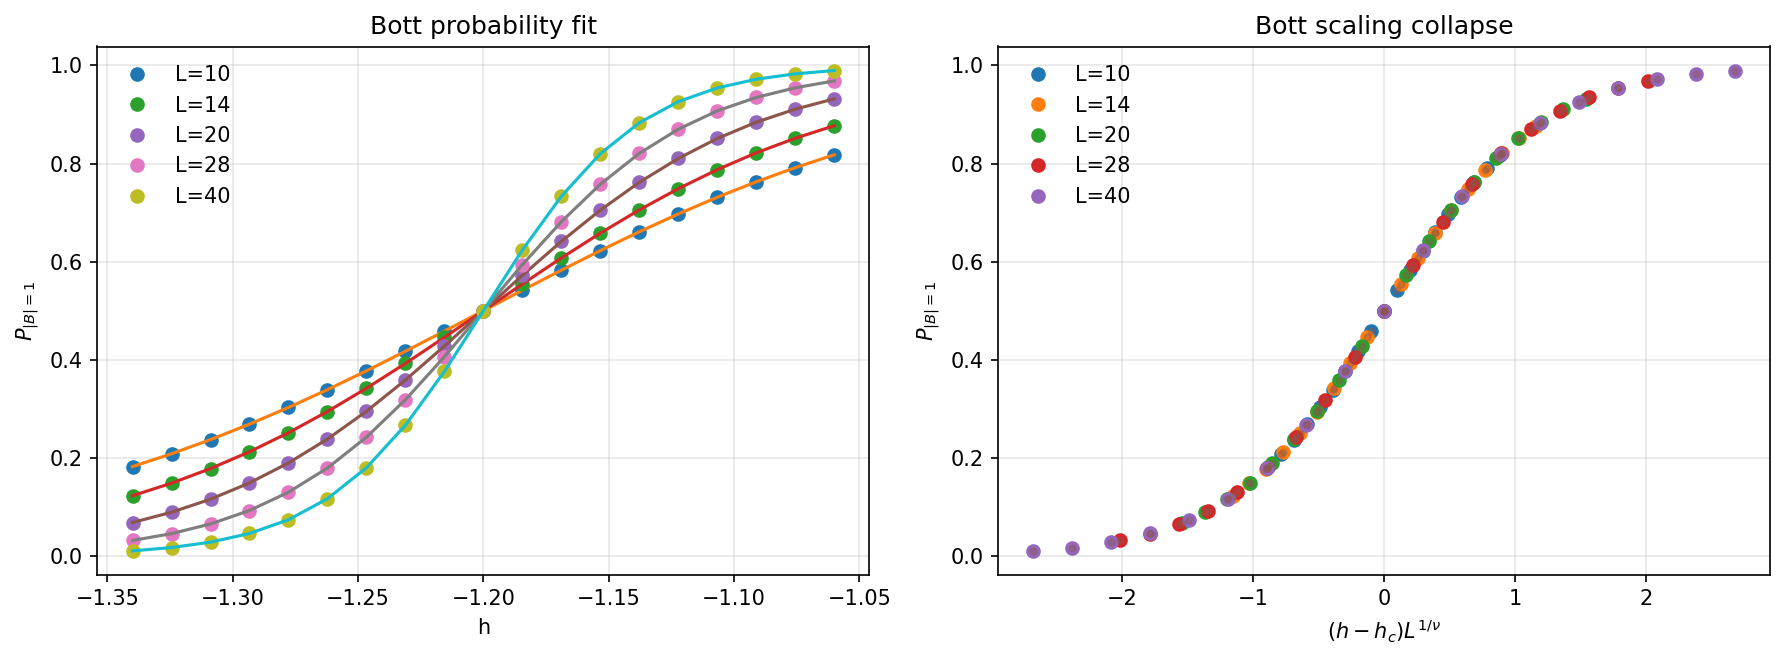


Transfer-matrix scaling result


,parameter,estimate,standard_error,ci_low,ci_high
0,hc,-1.200,0.000374,-1.200431,-1.199211
1,nu,1.250,0.007641,1.239762,1.261103
2,c0,1.350,0.001746,1.347994,1.353832
3,c1,0.420,0.006820,0.411282,0.430399
4,c2,0.055,0.002138,0.052456,0.058677


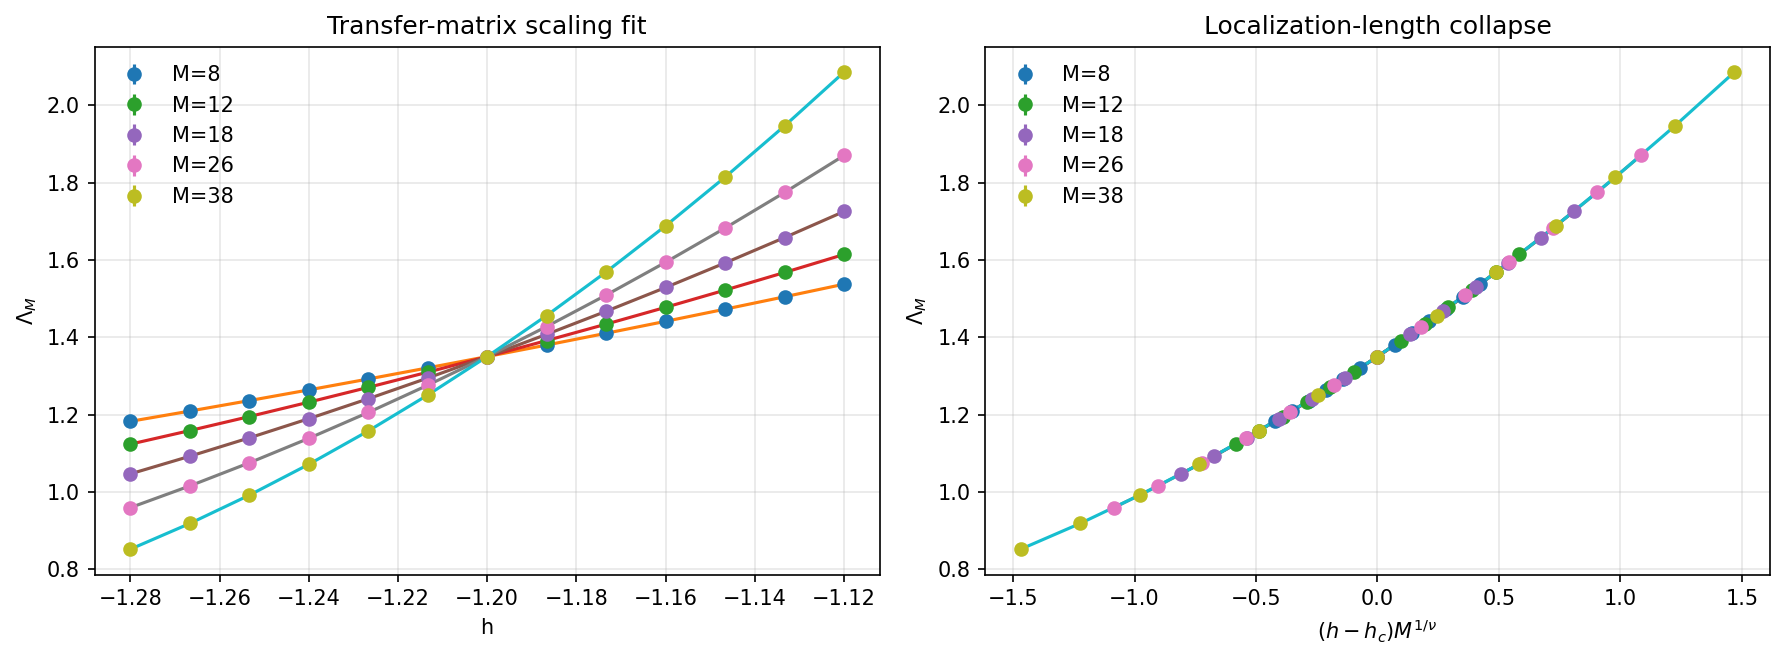

,check,value,expected,PASS
0,Bott fit succeeds,True,True,True
1,Bott nu recovers ground truth,1.24999,1.25,True
2,Bott hc recovers ground truth,-1.200005,-1.2,True
3,transfer fit succeeds,True,True,True
4,transfer nu recovers ground truth,1.25,1.25,True
5,transfer hc recovers ground truth,-1.2,-1.2,True
6,Bott bootstrap returns samples,12,12,True
7,transfer bootstrap returns samples,12,12,True



Recovered from Bott: hc=-1.20000478, nu=1.24999049
Recovered from transfer: hc=-1.20000000, nu=1.25000000

CRITICAL-EXPONENT SANITY CHECK PASSED.


In [3]:
# ============================================================
# exponents.py sanity check 1
# Critical exponent nu from:
#   A. Bott probability
#   B. transfer-matrix Lambda
# ============================================================

from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 0. Load local exponents.py freshly
# ------------------------------------------------------------

module_path = Path.cwd() / "exponents.py"

if not module_path.exists():
    raise FileNotFoundError(
        f"Cannot find exponents.py in:\n{Path.cwd()}"
    )

module_folder = str(
    module_path.parent.resolve()
)

if module_folder not in sys.path:
    sys.path.insert(
        0,
        module_folder,
    )

import exponents
importlib.reload(exponents)

import exponents as ex

print(
    "Loaded exponent module:",
    Path(exponents.__file__).resolve(),
)


# ============================================================
# 1. Known ground truth
# ============================================================

NU_TRUE = 1.25
HC_TRUE = -1.20


# ============================================================
# 2. Synthetic Bott-probability data
#
# P = logistic[1.7 * (h-hc) L^(1/nu)]
# ============================================================

bott_rows = []

for L in [10, 14, 20, 28, 40]:

    for h in np.linspace(
        -1.34,
        -1.06,
        19,
    ):

        x = (
            (h - HC_TRUE)
            * L ** (1.0 / NU_TRUE)
        )

        probability = (
            1.0
            / (
                1.0
                + np.exp(-1.7 * x)
            )
        )

        # Very large n makes the synthetic binomial probability
        # effectively exact while still testing the summary-data API.
        bott_rows.append(
            {
                "L": L,
                "h": h,
                "P_absB1": probability,
                "n": 100_000,
            }
        )

bott_test_data = pd.DataFrame(
    bott_rows
)

bott_config = ex.BottNuConfig(
    polynomial_order=1,
    hc_bounds=(-1.30, -1.10),
    nu_bounds=(0.5, 2.5),
    n_bootstrap=12,
    seed=2026,
)

bott_result = ex.fit_nu_from_bott(
    bott_test_data,
    config=bott_config,
)

print("\nBott scaling result")
display(
    bott_result.summary_frame()
)

ex.plot_bott_nu_result(
    bott_result
)

plt.show()


# ============================================================
# 3. Synthetic transfer-matrix data
#
# Lambda = 1.35 + 0.42 x + 0.055 x^2
# x = (h-hc) M^(1/nu)
#
# Symmetric realization offsets make the disorder mean exactly
# equal to the known scaling function while testing raw-data
# aggregation and SEM construction.
# ============================================================

transfer_rows = []

realization_offsets = np.array(
    [
        -0.012,
        -0.006,
        0.000,
        0.006,
        0.012,
    ]
)

for M in [8, 12, 18, 26, 38]:

    for h in np.linspace(
        -1.28,
        -1.12,
        13,
    ):

        x = (
            (h - HC_TRUE)
            * M ** (1.0 / NU_TRUE)
        )

        mean_lambda = (
            1.35
            + 0.42 * x
            + 0.055 * x**2
        )

        for seed, offset in enumerate(
            realization_offsets
        ):

            transfer_rows.append(
                {
                    "M": M,
                    "h": h,
                    "Lambda": (
                        mean_lambda
                        + offset
                    ),
                    "seed": seed,
                }
            )

transfer_test_data = pd.DataFrame(
    transfer_rows
)

transfer_config = ex.TransferNuConfig(
    polynomial_order=2,
    hc_bounds=(-1.26, -1.14),
    nu_bounds=(0.5, 2.5),
    include_irrelevant=False,
    n_bootstrap=12,
    seed=2027,
)

transfer_result = ex.fit_nu_from_transfer(
    transfer_test_data,
    config=transfer_config,
)

print("\nTransfer-matrix scaling result")
display(
    transfer_result.summary_frame()
)

ex.plot_transfer_nu_result(
    transfer_result
)

plt.show()


# ============================================================
# 4. Pass/fail tests
# ============================================================

nu_bott = bott_result.parameters["nu"]
hc_bott = bott_result.parameters["hc"]

nu_transfer = transfer_result.parameters["nu"]
hc_transfer = transfer_result.parameters["hc"]

checks = pd.DataFrame(
    [
        {
            "check": "Bott fit succeeds",
            "value": bott_result.success,
            "expected": True,
            "PASS": bott_result.success,
        },
        {
            "check": "Bott nu recovers ground truth",
            "value": nu_bott,
            "expected": NU_TRUE,
            "PASS": abs(
                nu_bott - NU_TRUE
            ) < 2.0e-4,
        },
        {
            "check": "Bott hc recovers ground truth",
            "value": hc_bott,
            "expected": HC_TRUE,
            "PASS": abs(
                hc_bott - HC_TRUE
            ) < 2.0e-5,
        },
        {
            "check": "transfer fit succeeds",
            "value": transfer_result.success,
            "expected": True,
            "PASS": transfer_result.success,
        },
        {
            "check": "transfer nu recovers ground truth",
            "value": nu_transfer,
            "expected": NU_TRUE,
            "PASS": abs(
                nu_transfer - NU_TRUE
            ) < 2.0e-4,
        },
        {
            "check": "transfer hc recovers ground truth",
            "value": hc_transfer,
            "expected": HC_TRUE,
            "PASS": abs(
                hc_transfer - HC_TRUE
            ) < 2.0e-5,
        },
        {
            "check": "Bott bootstrap returns samples",
            "value": (
                0
                if bott_result.bootstrap_samples is None
                else len(
                    bott_result.bootstrap_samples
                )
            ),
            "expected": 12,
            "PASS": (
                bott_result.bootstrap_samples
                is not None
                and len(
                    bott_result.bootstrap_samples
                ) == 12
            ),
        },
        {
            "check": "transfer bootstrap returns samples",
            "value": (
                0
                if transfer_result.bootstrap_samples is None
                else len(
                    transfer_result.bootstrap_samples
                )
            ),
            "expected": 12,
            "PASS": (
                transfer_result.bootstrap_samples
                is not None
                and len(
                    transfer_result.bootstrap_samples
                ) == 12
            ),
        },
    ]
)

display(checks)

print()
print(
    f"Recovered from Bott: "
    f"hc={hc_bott:.8f}, "
    f"nu={nu_bott:.8f}"
)

print(
    f"Recovered from transfer: "
    f"hc={hc_transfer:.8f}, "
    f"nu={nu_transfer:.8f}"
)

failed = checks.loc[
    ~checks["PASS"],
    "check",
].tolist()

if failed:
    raise AssertionError(
        "Critical-exponent sanity check failed:\n- "
        + "\n- ".join(failed)
    )

print()
print(
    "CRITICAL-EXPONENT SANITY CHECK PASSED."
)

,parameter,estimate,standard_error,ci_low,ci_high
0,z,1.400000,3.666946e-16,1.400000,1.400000
1,alpha,0.428571,1.833473e-16,0.428571,0.428571
2,amplitude,2.750000,2.039473e-15,2.750000,2.750000


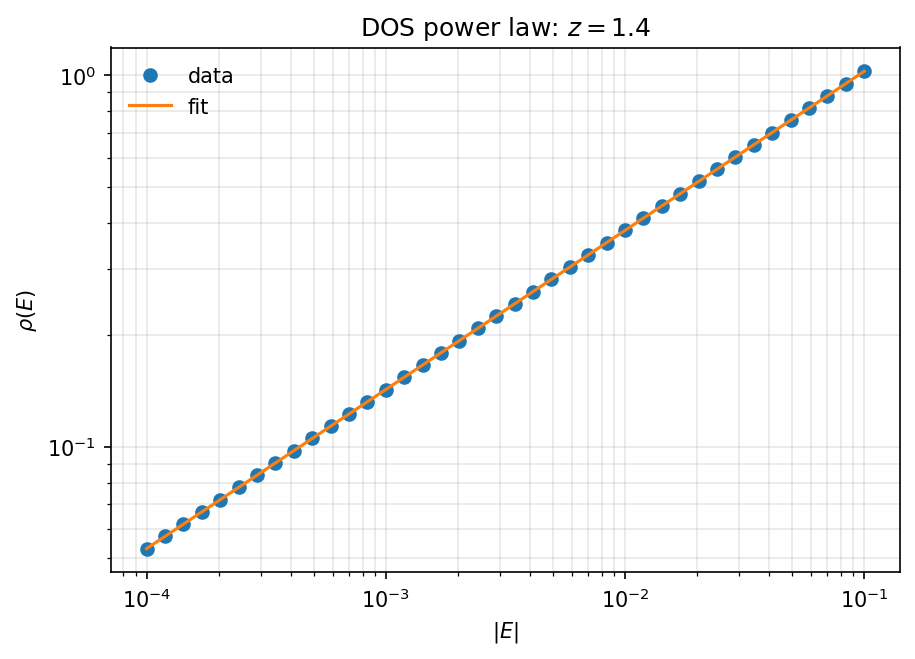

,check,value,expected,PASS
0,DOS fit succeeds,True,True,True
1,z recovers ground truth,1.4,1.4,True
2,alpha recovers ground truth,0.428571,0.428571,True
3,amplitude recovers ground truth,2.75,2.75,True
4,DOS bootstrap returns samples,12,12,True



True z       = 1.4000000000
Recovered z  = 1.4000000000
True alpha   = 0.4285714286
Recovered alpha = 0.4285714286

DYNAMICAL-EXPONENT SANITY CHECK PASSED.


In [4]:
# ============================================================
# exponents.py sanity check 2
# Dynamical exponent z from DOS power-law scaling
# ============================================================

from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Load local module freshly
# ------------------------------------------------------------

module_path = Path.cwd() / "exponents.py"

if not module_path.exists():
    raise FileNotFoundError(
        f"Cannot find exponents.py in:\n{Path.cwd()}"
    )

module_folder = str(
    module_path.parent.resolve()
)

if module_folder not in sys.path:
    sys.path.insert(
        0,
        module_folder,
    )

import exponents
importlib.reload(exponents)

import exponents as ex


# ============================================================
# 1. Known DOS scaling
# ============================================================

DIMENSION = 2.0
Z_TRUE = 1.40
AMPLITUDE_TRUE = 2.75

ALPHA_TRUE = (
    DIMENSION / Z_TRUE
    - 1.0
)

energy = np.logspace(
    -4,
    -1,
    40,
)

rho = (
    AMPLITUDE_TRUE
    * energy**ALPHA_TRUE
)

rho_error = (
    0.01
    * rho
)

dos_test_data = pd.DataFrame(
    {
        "E": energy,
        "rho": rho,
        "rho_error": rho_error,
    }
)


# ============================================================
# 2. Fit z
# ============================================================

dos_config = ex.DOSZConfig(
    energy_col="E",
    dos_col="rho",
    error_col="rho_error",
    dimension=DIMENSION,
    energy_window=(
        1.0e-4,
        1.0e-1,
    ),
    n_bootstrap=12,
    seed=2028,
)

dos_result = ex.fit_z_from_dos_powerlaw(
    dos_test_data,
    config=dos_config,
)

display(
    dos_result.summary_frame()
)

ex.plot_dos_z_result(
    dos_result
)

plt.show()


# ============================================================
# 3. Pass/fail
# ============================================================

z_fit = dos_result.parameters["z"]
alpha_fit = dos_result.parameters["alpha"]
amplitude_fit = dos_result.parameters[
    "amplitude"
]

checks = pd.DataFrame(
    [
        {
            "check": "DOS fit succeeds",
            "value": dos_result.success,
            "expected": True,
            "PASS": dos_result.success,
        },
        {
            "check": "z recovers ground truth",
            "value": z_fit,
            "expected": Z_TRUE,
            "PASS": abs(
                z_fit - Z_TRUE
            ) < 1.0e-10,
        },
        {
            "check": "alpha recovers ground truth",
            "value": alpha_fit,
            "expected": ALPHA_TRUE,
            "PASS": abs(
                alpha_fit - ALPHA_TRUE
            ) < 1.0e-10,
        },
        {
            "check": "amplitude recovers ground truth",
            "value": amplitude_fit,
            "expected": AMPLITUDE_TRUE,
            "PASS": abs(
                amplitude_fit
                - AMPLITUDE_TRUE
            ) < 1.0e-10,
        },
        {
            "check": "DOS bootstrap returns samples",
            "value": (
                0
                if dos_result.bootstrap_samples is None
                else len(
                    dos_result.bootstrap_samples
                )
            ),
            "expected": 12,
            "PASS": (
                dos_result.bootstrap_samples
                is not None
                and len(
                    dos_result.bootstrap_samples
                ) == 12
            ),
        },
    ]
)

display(checks)

print()
print(
    f"True z       = {Z_TRUE:.10f}"
)

print(
    f"Recovered z  = {z_fit:.10f}"
)

print(
    f"True alpha   = {ALPHA_TRUE:.10f}"
)

print(
    f"Recovered alpha = {alpha_fit:.10f}"
)

failed = checks.loc[
    ~checks["PASS"],
    "check",
].tolist()

if failed:
    raise AssertionError(
        "Dynamical-exponent sanity check failed:\n- "
        + "\n- ".join(failed)
    )

print()
print(
    "DYNAMICAL-EXPONENT SANITY CHECK PASSED."
)

,L,q,Pq_computed,Pq_expected,absolute_error
0,8,0.5,8.000000,8.000000,0.0
1,8,1.5,0.125000,0.125000,0.0
2,8,2.0,0.015625,0.015625,0.0
3,8,2.5,0.001953,0.001953,0.0
4,8,3.0,0.000244,0.000244,0.0
5,16,0.5,16.000000,16.000000,0.0
6,16,1.5,0.062500,0.062500,0.0
7,16,2.0,0.003906,0.003906,0.0
8,16,2.5,0.000244,0.000244,0.0
9,16,3.0,0.000015,0.000015,0.0


,q,n_sizes,tau_typical,tau_typical_error,Dq_typical,Dq_typical_error,chi2_typical,dof_typical,tau_average,tau_average_error,...,Dq_typical_ci_high,Dq_typical_bootstrap_error,tau_average_ci_low,tau_average_ci_high,tau_average_bootstrap_error,Dq_average_ci_low,Dq_average_ci_high,Dq_average_bootstrap_error,tau_true,Dq_true
0,0.5,6.0,-0.97,1.388650e-16,1.94,2.777300e-16,1.972152e-31,4.0,-0.97,4.165949e-16,...,1.965929,0.009862,-0.982989,-0.968103,0.004936,1.936206,1.965978,0.009873,-0.97,1.94
1,1.5,6.0,0.91,5.378218e-16,1.82,1.075644e-15,2.958228e-30,4.0,0.91,1.963847e-16,...,1.831495,0.011919,0.898648,0.915771,0.005933,1.797295,1.831541,0.011867,0.91,1.82
2,2.0,6.0,1.76,1.739973e-15,1.76,1.739973e-15,3.096279e-29,4.0,1.76,7.855390e-16,...,1.766968,0.006121,1.747026,1.767011,0.006152,1.747026,1.767011,0.006152,1.76,1.76
3,2.5,6.0,2.55,1.075644e-15,1.70,7.170957e-16,1.183291e-29,4.0,2.55,8.782592e-16,...,1.706847,0.004607,2.541140,2.560256,0.006918,1.694094,1.706838,0.004612,2.55,1.70
4,3.0,6.0,3.28,1.495622e-15,1.64,7.478108e-16,2.287697e-29,4.0,3.28,1.272719e-15,...,1.645331,0.003490,3.269276,3.290602,0.006987,1.634638,1.645301,0.003493,3.28,1.64


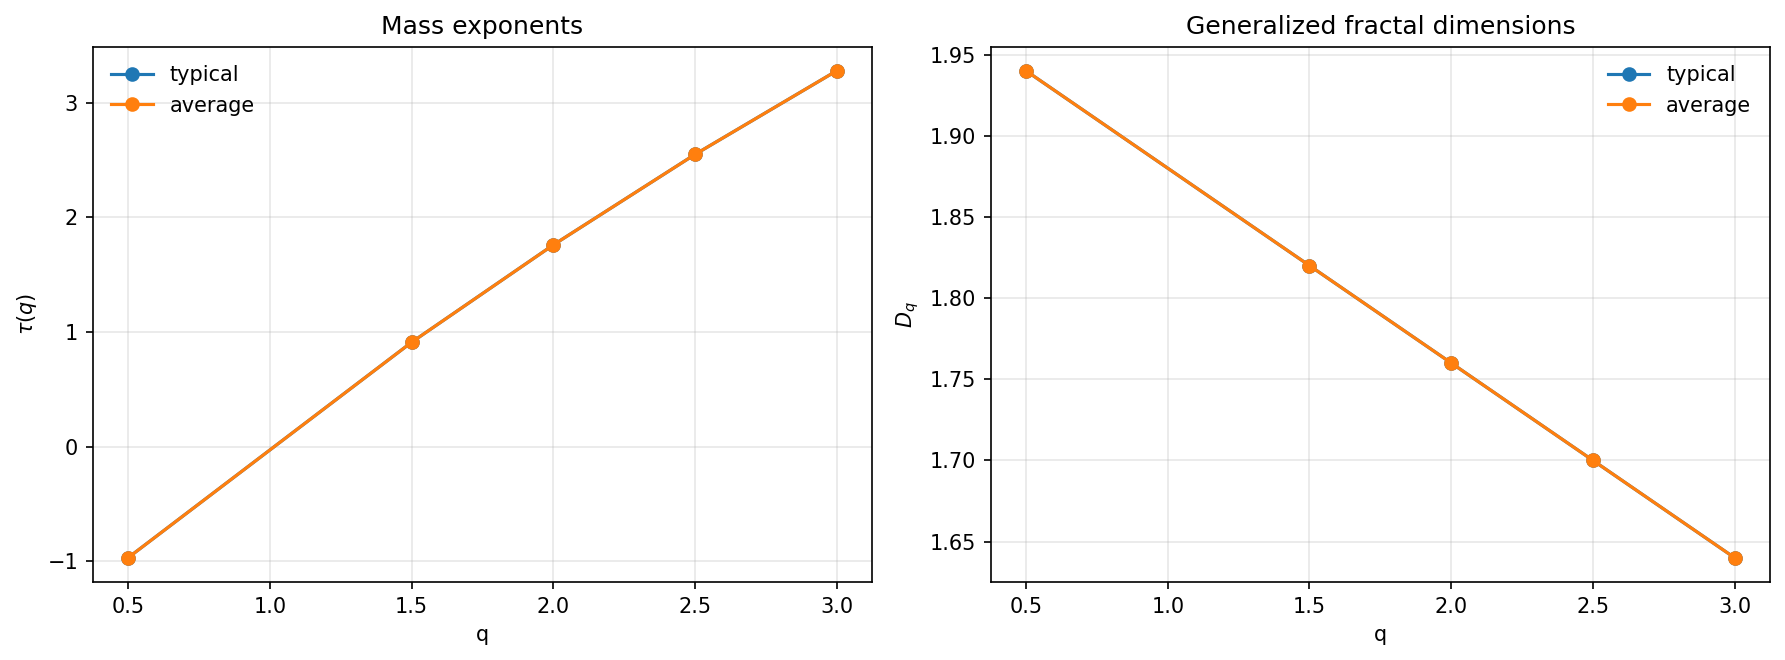

,check,value,expected,PASS
0,uniform 2D Pq formula,0.0,< 1e-12,True
1,typical tau(q) ground truth,0.0,< 1e-12,True
2,average tau(q) ground truth,0.0,< 1e-12,True
3,typical Dq ground truth,0.0,< 1e-12,True
4,average Dq ground truth,0.0,< 1e-12,True
5,typical Legendre spectrum exists,True,True,True
6,average Legendre spectrum exists,True,True,True
7,multifractal bootstrap returns samples,12,12,True



MULTIFRACTAL SANITY CHECK PASSED.


In [5]:
# ============================================================
# exponents.py sanity check 3
# Generalized participation ratios and multifractal exponents
# ============================================================

from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Load local module freshly
# ------------------------------------------------------------

module_path = Path.cwd() / "exponents.py"

if not module_path.exists():
    raise FileNotFoundError(
        f"Cannot find exponents.py in:\n{Path.cwd()}"
    )

module_folder = str(
    module_path.parent.resolve()
)

if module_folder not in sys.path:
    sys.path.insert(
        0,
        module_folder,
    )

import exponents
importlib.reload(exponents)

import exponents as ex


# ============================================================
# 1. Direct GPR check for uniform 2D probability
# ============================================================

q_values = np.array(
    [
        0.5,
        1.5,
        2.0,
        2.5,
        3.0,
    ]
)

uniform_rows = []

for L in [8, 16]:

    probability = np.ones(
        L * L,
        dtype=float,
    )

    probability /= probability.sum()

    gpr = (
        ex.generalized_participation_ratios(
            probability,
            q_values=q_values,
            shape=(L, L),
            box_size=1,
        )
    )

    expected_Pq = (
        L
        ** (
            -2.0
            * (q_values - 1.0)
        )
    )

    for index, q in enumerate(
        q_values
    ):

        uniform_rows.append(
            {
                "L": L,
                "q": q,
                "Pq_computed": (
                    gpr.loc[index, "Pq"]
                ),
                "Pq_expected": (
                    expected_Pq[index]
                ),
                "absolute_error": abs(
                    gpr.loc[index, "Pq"]
                    - expected_Pq[index]
                ),
            }
        )

uniform_check = pd.DataFrame(
    uniform_rows
)

display(uniform_check)


# ============================================================
# 2. Synthetic multifractal spectrum
#
# tau(q) = 2(q-1) - gamma q(q-1)
# D_q    = 2 - gamma q
# ============================================================

GAMMA = 0.12

sizes = [
    8,
    12,
    18,
    26,
    38,
    54,
]

# Symmetric log offsets:
# typical average of ln(Pq) is exactly the ground-truth value.
# Their effect on arithmetic mean is an L-independent prefactor,
# so average tau(q) is also unchanged.
log_offsets = np.array(
    [
        -0.030,
        -0.015,
        0.000,
        0.015,
        0.030,
    ]
)

multifractal_rows = []

for L in sizes:

    for q in q_values:

        tau_true = (
            2.0 * (q - 1.0)
            - GAMMA * q * (q - 1.0)
        )

        base_Pq = (
            L ** (-tau_true)
        )

        for realization, offset in enumerate(
            log_offsets
        ):

            multifractal_rows.append(
                {
                    "L": L,
                    "q": q,
                    "Pq": (
                        base_Pq
                        * np.exp(offset)
                    ),
                    "realization": realization,
                }
            )

multifractal_test_data = pd.DataFrame(
    multifractal_rows
)


# ============================================================
# 3. Fit tau(q), D_q and Legendre spectrum
# ============================================================

multifractal_config = ex.MultifractalConfig(
    compute_typical=True,
    compute_average=True,
    n_bootstrap=12,
    seed=2029,
)

multifractal_result = (
    ex.fit_multifractal_spectrum(
        multifractal_test_data,
        config=multifractal_config,
    )
)

spectrum = multifractal_result.spectrum.copy()

spectrum["tau_true"] = (
    2.0 * (spectrum["q"] - 1.0)
    - GAMMA
    * spectrum["q"]
    * (spectrum["q"] - 1.0)
)

spectrum["Dq_true"] = (
    2.0
    - GAMMA * spectrum["q"]
)

display(spectrum)

ex.plot_multifractal_result(
    multifractal_result
)

plt.show()


# ============================================================
# 4. Pass/fail
# ============================================================

max_uniform_error = float(
    uniform_check[
        "absolute_error"
    ].max()
)

max_tau_typical_error = float(
    np.max(
        np.abs(
            spectrum["tau_typical"]
            - spectrum["tau_true"]
        )
    )
)

max_tau_average_error = float(
    np.max(
        np.abs(
            spectrum["tau_average"]
            - spectrum["tau_true"]
        )
    )
)

max_Dq_typical_error = float(
    np.max(
        np.abs(
            spectrum["Dq_typical"]
            - spectrum["Dq_true"]
        )
    )
)

max_Dq_average_error = float(
    np.max(
        np.abs(
            spectrum["Dq_average"]
            - spectrum["Dq_true"]
        )
    )
)

checks = pd.DataFrame(
    [
        {
            "check": "uniform 2D Pq formula",
            "value": max_uniform_error,
            "expected": "< 1e-12",
            "PASS": (
                max_uniform_error
                < 1.0e-12
            ),
        },
        {
            "check": "typical tau(q) ground truth",
            "value": max_tau_typical_error,
            "expected": "< 1e-12",
            "PASS": (
                max_tau_typical_error
                < 1.0e-12
            ),
        },
        {
            "check": "average tau(q) ground truth",
            "value": max_tau_average_error,
            "expected": "< 1e-12",
            "PASS": (
                max_tau_average_error
                < 1.0e-12
            ),
        },
        {
            "check": "typical Dq ground truth",
            "value": max_Dq_typical_error,
            "expected": "< 1e-12",
            "PASS": (
                max_Dq_typical_error
                < 1.0e-12
            ),
        },
        {
            "check": "average Dq ground truth",
            "value": max_Dq_average_error,
            "expected": "< 1e-12",
            "PASS": (
                max_Dq_average_error
                < 1.0e-12
            ),
        },
        {
            "check": "typical Legendre spectrum exists",
            "value": (
                "alpha_typical"
                in spectrum.columns
            ),
            "expected": True,
            "PASS": (
                "alpha_typical"
                in spectrum.columns
                and "f_alpha_typical"
                in spectrum.columns
            ),
        },
        {
            "check": "average Legendre spectrum exists",
            "value": (
                "alpha_average"
                in spectrum.columns
            ),
            "expected": True,
            "PASS": (
                "alpha_average"
                in spectrum.columns
                and "f_alpha_average"
                in spectrum.columns
            ),
        },
        {
            "check": "multifractal bootstrap returns samples",
            "value": (
                0
                if multifractal_result.bootstrap_samples is None
                else multifractal_result[
                    "replicate"
                ].nunique()
            )
            if False
            else (
                0
                if multifractal_result.bootstrap_samples is None
                else multifractal_result.bootstrap_samples[
                    "replicate"
                ].nunique()
            ),
            "expected": 12,
            "PASS": (
                multifractal_result.bootstrap_samples
                is not None
                and multifractal_result.bootstrap_samples[
                    "replicate"
                ].nunique() == 12
            ),
        },
    ]
)

display(checks)

failed = checks.loc[
    ~checks["PASS"],
    "check",
].tolist()

if failed:
    raise AssertionError(
        "Multifractal sanity check failed:\n- "
        + "\n- ".join(failed)
    )

print()
print(
    "MULTIFRACTAL SANITY CHECK PASSED."
)